# 01 — Exploration de la houle et contrôle qualité du cache

Ce notebook regarde la matière première du produit : **701 280 heures de houle**,
20 spots × 4 ans, lues depuis le cache parquet versionné dans le dépôt.

Il répond à trois questions, dans cet ordre :

1. **Le cache est-il complet et sain ?** Un cache partiel produit un classement faux
   et parfaitement plausible. C'est le mode de panne le plus dangereux du projet.
2. **Pourquoi `swell_wave_height` et jamais `wave_height` ?** Cette décision coûte
   six ans d'archive. Elle mérite d'être montrée plutôt qu'affirmée.
3. **Le ratio période de pic → période moyenne tient-il ?** `config.py` renvoie
   explicitement sa validation à ce notebook.

Aucun appel réseau : tout vient du disque.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

from nalu.config import CONFIG, SWELL_HEIGHT
from nalu.ingest.openmeteo import SNAPSHOT_DIR
from nalu.palette import CLAIR, style_matplotlib
from nalu.spots import load_raw_spots

plt.rcParams.update(style_matplotlib(CLAIR))
pl.Config.set_tbl_rows(25)

spots = {s.id: s for s in load_raw_spots()}
annees = list(CONFIG.years)
print(f"{len(spots)} spots, annees {annees[0]}-{annees[-1]}")

20 spots, annees 2022-2025


## 1. Le cache : volume et intégrité

In [2]:
fichiers = sorted((SNAPSHOT_DIR / "hourly").glob("*/*.parquet"))
heures = pl.concat([pl.read_parquet(f) for f in fichiers])

print(f"{len(fichiers)} fichiers horaires")
print(f"{heures.height:,} lignes".replace(",", " "))
print(f"{heures['spot_id'].n_unique()} spots distincts")
print(f"de {heures['time'].min()} a {heures['time'].max()}")

80 fichiers horaires
701 280 lignes
20 spots distincts
de 2022-01-01 00:00:00+00:00 a 2025-12-31 23:00:00+00:00


### Taux de valeurs manquantes par spot et par année

`CONFIG.null_alert_ratio` fixe à 5 % le seuil au-delà duquel une année n'est plus
représentative. Ce n'est pas un contrôle décoratif : c'est ce qui empêche une
moyenne d'être calculée sur un mois à moitié vide.

In [3]:
manquants = (
    heures.with_columns(pl.col("time").dt.year().alias("annee"))
    .group_by("spot_id", "annee")
    .agg(
        pl.len().alias("heures"),
        (pl.col(SWELL_HEIGHT).is_null().sum() / pl.len()).alias("taux_nul"),
    )
    .sort("taux_nul", descending=True)
)

pires = manquants.head(8)
print(f"Seuil d'alerte : {CONFIG.null_alert_ratio:.0%}\n")
print("Les 8 couples spot-annee les plus lacunaires :")
print(pires)

au_dessus = manquants.filter(pl.col("taux_nul") > CONFIG.null_alert_ratio)
print(f"\nCouples au-dessus du seuil : {au_dessus.height}")
if au_dessus.is_empty():
    print("Aucun. Le cache est utilisable tel quel.")

Seuil d'alerte : 5%

Les 8 couples spot-annee les plus lacunaires :
shape: (8, 4)
┌────────────────────┬───────┬────────┬──────────┐
│ spot_id            ┆ annee ┆ heures ┆ taux_nul │
│ ---                ┆ ---   ┆ ---    ┆ ---      │
│ str                ┆ i32   ┆ u32    ┆ f64      │
╞════════════════════╪═══════╪════════╪══════════╡
│ jeffreys-bay       ┆ 2023  ┆ 8760   ┆ 0.0      │
│ anchor-point       ┆ 2022  ┆ 8760   ┆ 0.0      │
│ jeffreys-bay       ┆ 2022  ┆ 8760   ┆ 0.0      │
│ tres-palmas        ┆ 2025  ┆ 8760   ┆ 0.0      │
│ ponta-preta        ┆ 2025  ┆ 8760   ┆ 0.0      │
│ peniche-supertubos ┆ 2023  ┆ 8760   ┆ 0.0      │
│ thurso-east        ┆ 2023  ┆ 8760   ┆ 0.0      │
│ playa-grande       ┆ 2024  ┆ 8784   ┆ 0.0      │
└────────────────────┴───────┴────────┴──────────┘

Couples au-dessus du seuil : 0
Aucun. Le cache est utilisable tel quel.


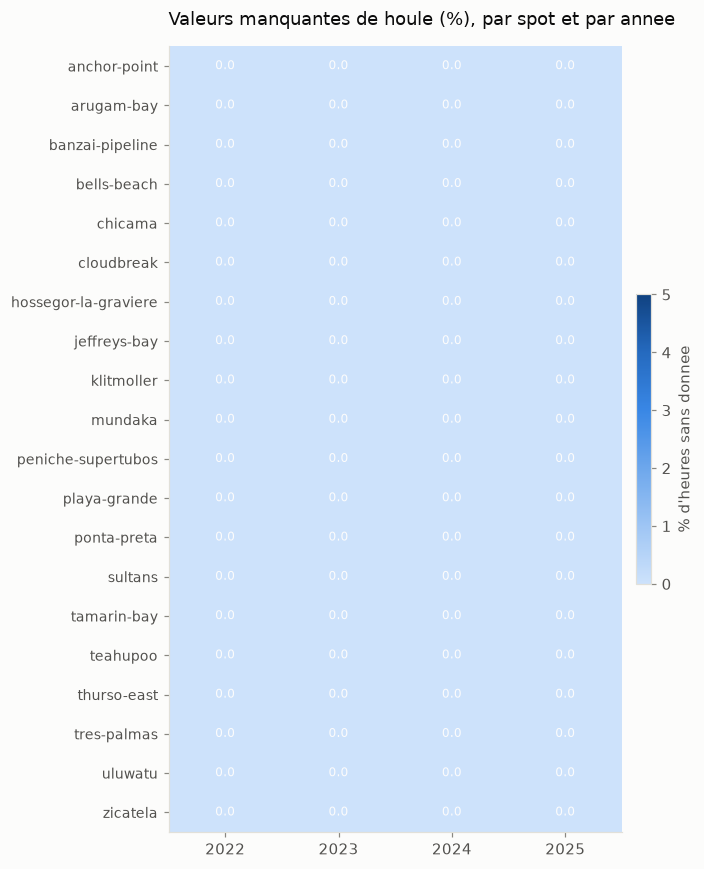

In [4]:
# Carte de chaleur du taux de valeurs manquantes : magnitude -> rampe sequentielle,
# une seule teinte, du clair au fonce. Jamais un arc-en-ciel.
pivot = (
    manquants.sort("spot_id")
    .pivot(values="taux_nul", index="spot_id", on="annee")
    .sort("spot_id")
)
noms = pivot["spot_id"].to_list()
matrice = pivot.select([str(a) for a in annees]).to_numpy() * 100

rampe = LinearSegmentedColormap.from_list("nalu", CLAIR["rampe"])

fig, ax = plt.subplots(figsize=(6.5, 8))
image = ax.imshow(matrice, cmap=rampe, aspect="auto", vmin=0,
                  vmax=max(matrice.max(), CONFIG.null_alert_ratio * 100))
ax.set_xticks(range(len(annees)), [str(a) for a in annees])
ax.set_yticks(range(len(noms)), noms, fontsize=9)
ax.grid(visible=False)
for i in range(len(noms)):
    for j in range(len(annees)):
        ax.text(j, i, f"{matrice[i, j]:.1f}", ha="center", va="center", fontsize=8,
                color=CLAIR["encre"] if matrice[i, j] < matrice.max() * 0.6 else CLAIR["surface"])
ax.set_title("Valeurs manquantes de houle (%), par spot et par annee",
             loc="left", pad=14, fontsize=12)
barre = fig.colorbar(image, ax=ax, fraction=0.03, pad=0.03)
barre.set_label("% d'heures sans donnee", color=CLAIR["encre_2"])
plt.tight_layout()
plt.show()

## 2. Pourquoi `swell_wave_height` et jamais `wave_height`

C'est **la** décision qui a coûté six ans d'archive : Open-Meteo ne sert la partition
de houle que depuis décembre 2021, alors que la mer totale remonte à 1940.

`wave_height` agrège la houle **et** la mer du vent. Un clapot de 1,5 m à 5 s et une
houle de 1,5 m à 14 s y ont la même hauteur — et l'un est inutilisable quand l'autre
est parfait. Voici l'écart, mesuré.

In [5]:
ecart = (
    heures.select(SWELL_HEIGHT, "wave_height", "wind_wave_height")
    .drop_nulls()
    .with_columns((pl.col("wave_height") - pl.col(SWELL_HEIGHT)).alias("surplus"))
)

q = ecart.select(
    pl.col(SWELL_HEIGHT).median().alias("houle_mediane"),
    pl.col("wave_height").median().alias("mer_totale_mediane"),
    pl.col("surplus").median().alias("surplus_median"),
    (pl.col("surplus") > 0.5).mean().alias("part_surplus_sup_50cm"),
)
print(q)
print()
print(f"La mer totale surestime la houle de {q['surplus_median'][0]:.2f} m en mediane.")
print(f"Sur {q['part_surplus_sup_50cm'][0]:.0%} des heures, l'ecart depasse 50 cm.")

shape: (1, 4)
┌───────────────┬────────────────────┬────────────────┬───────────────────────┐
│ houle_mediane ┆ mer_totale_mediane ┆ surplus_median ┆ part_surplus_sup_50cm │
│ ---           ┆ ---                ┆ ---            ┆ ---                   │
│ f32           ┆ f32                ┆ f32            ┆ f64                   │
╞═══════════════╪════════════════════╪════════════════╪═══════════════════════╡
│ 1.04          ┆ 1.32               ┆ 0.22           ┆ 0.13917               │
└───────────────┴────────────────────┴────────────────┴───────────────────────┘

La mer totale surestime la houle de 0.22 m en mediane.
Sur 14% des heures, l'ecart depasse 50 cm.


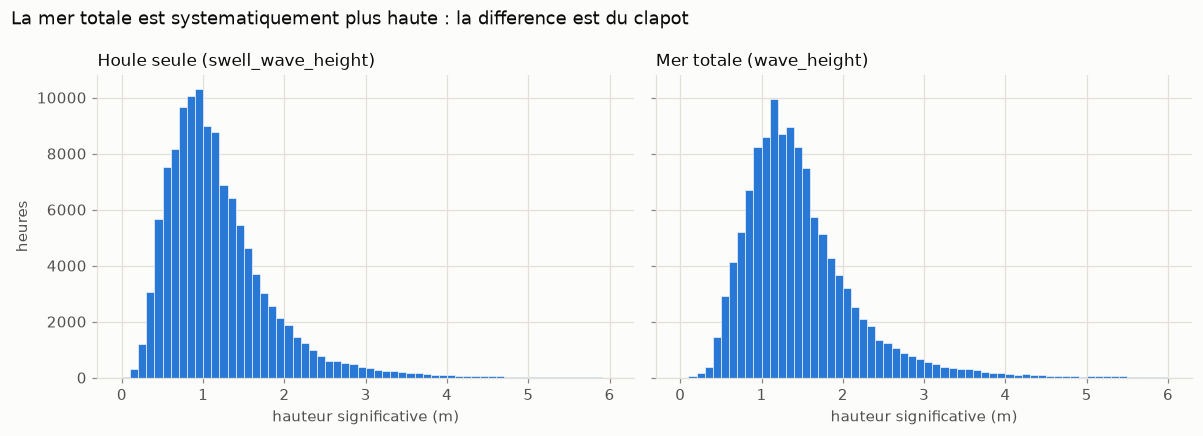

In [6]:
# Deux distributions, en petits multiples plutot qu'une superposition : le projet
# ne definit qu'UNE teinte categorielle, et en inventer une seconde a l'oeil est
# exactement ce que le systeme de dataviz interdit.
echantillon = ecart.sample(n=min(120_000, ecart.height), seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (colonne, titre) in zip(
    axes,
    [(SWELL_HEIGHT, "Houle seule (swell_wave_height)"),
     ("wave_height", "Mer totale (wave_height)")],
    strict=True,
):
    ax.hist(echantillon[colonne].to_numpy(), bins=60, range=(0, 6),
            color=CLAIR["serie"], edgecolor=CLAIR["surface"], linewidth=0.4)
    ax.set_title(titre, loc="left", fontsize=11)
    ax.set_xlabel("hauteur significative (m)")
axes[0].set_ylabel("heures")
fig.suptitle("La mer totale est systematiquement plus haute : la difference est du clapot",
             x=0.01, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

**Ce que montrent ces deux histogrammes.** La mer totale est décalée vers la
droite. Ce décalage n'est pas du signal, c'est de la mer du vent : de la hauteur qui
ne produit pas de vague surfable. Un modèle bâti sur `wave_height` compterait ces
heures-là comme bonnes.

C'est la raison pour laquelle **quatre ans de houle pure valent mieux que dix ans de
mer confondue** — et pourquoi `SWELL_HEIGHT` est figé dans `config.py` avec un test
qui échoue si on lui substitue `wave_height`.

## 3. Le ratio période de pic → période moyenne

`config.py` fixe `peak_to_mean_period_ratio = 0.85` et renvoie explicitement sa
validation à ce notebook. Le problème qu'il résout :

- les guides de surf publient une période **de pic** — c'est ce qui alimente
  `swell_peak_period_min` du référentiel ;
- Open-Meteo ne sert qu'une période **moyenne** ; `swell_wave_peak_period` est vide.

Comparer un seuil de pic à une période moyenne rend les spots artificiellement morts.
Voici l'ordre de grandeur des périodes moyennes réellement servies.

In [7]:
periodes = (
    heures.select("spot_id", "swell_wave_period")
    .drop_nulls()
    .group_by("spot_id")
    .agg(
        pl.col("swell_wave_period").median().alias("periode_moyenne_mediane"),
        pl.col("swell_wave_period").quantile(0.9).alias("periode_moyenne_p90"),
    )
    .join(
        pl.DataFrame({
            "spot_id": list(spots),
            "seuil_pic_source": [spots[i].swell_peak_period_min for i in spots],
        }),
        on="spot_id",
    )
    .with_columns(
        (pl.col("seuil_pic_source") * CONFIG.peak_to_mean_period_ratio).alias("seuil_converti"),
        (pl.col("periode_moyenne_mediane") / pl.col("seuil_pic_source")).alias("ratio_observe"),
    )
    .sort("ratio_observe")
)
print(f"Ratio applique par le modele : {CONFIG.peak_to_mean_period_ratio}")
print()
periodes.select("spot_id", "periode_moyenne_mediane", "seuil_pic_source",
                "seuil_converti", "ratio_observe")

Ratio applique par le modele : 0.85

spot_id,periode_moyenne_mediane,seuil_pic_source,seuil_converti,ratio_observe
str,f32,f64,f64,f64
"""sultans""",7.05,13.0,11.05,0.542308
"""tres-palmas""",7.2,13.0,11.05,0.553846
"""banzai-pipeline""",7.75,12.0,10.2,0.645833
"""anchor-point""",7.6,11.0,9.35,0.690909
"""teahupoo""",9.55,13.0,11.05,0.734615
"""jeffreys-bay""",8.35,11.0,9.35,0.759091
"""ponta-preta""",7.6,10.0,8.5,0.76
"""mundaka""",8.55,11.0,9.35,0.777273
"""zicatela""",10.45,13.0,11.05,0.803846


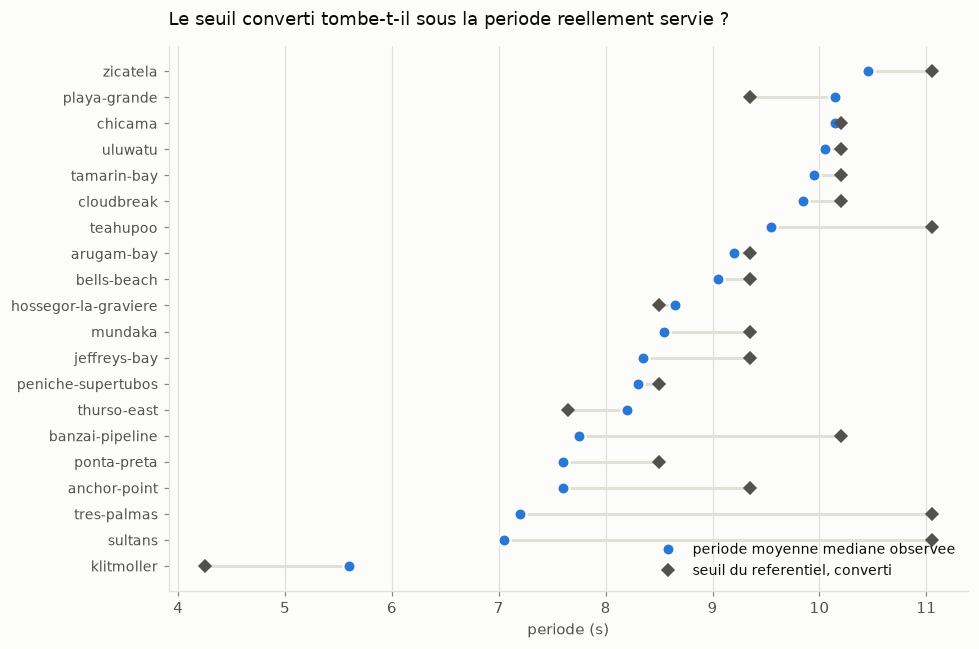

4/20 spots ont une periode mediane AU-DESSUS de leur seuil converti.
Un spot dont le seuil converti reste au-dessus de sa periode mediane ne sera
surfable que dans la queue haute de sa distribution — ce qui peut etre juste,
mais devient suspect si p_surf tombe a zero.


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ordre = periodes.sort("periode_moyenne_mediane")
y = np.arange(ordre.height)

ax.hlines(y, ordre["seuil_converti"], ordre["periode_moyenne_mediane"],
          color=CLAIR["grille"], linewidth=2, zorder=1)
ax.plot(ordre["periode_moyenne_mediane"], y, "o", color=CLAIR["serie"],
        markeredgecolor=CLAIR["surface"], markeredgewidth=1.5, zorder=3,
        label="periode moyenne mediane observee")
ax.plot(ordre["seuil_converti"], y, "D", color=CLAIR["encre_2"], markersize=6,
        zorder=3, label="seuil du referentiel, converti")

ax.set_yticks(y, ordre["spot_id"].to_list(), fontsize=9)
ax.set_xlabel("periode (s)")
ax.set_title("Le seuil converti tombe-t-il sous la periode reellement servie ?",
             loc="left", pad=14, fontsize=12)
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

sous = (ordre["periode_moyenne_mediane"] > ordre["seuil_converti"]).sum()
print(f"{sous}/{ordre.height} spots ont une periode mediane AU-DESSUS de leur seuil converti.")
print("Un spot dont le seuil converti reste au-dessus de sa periode mediane ne sera")
print("surfable que dans la queue haute de sa distribution — ce qui peut etre juste,")
print("mais devient suspect si p_surf tombe a zero.")

**Lecture, et elle n'est pas rassurante.** Sur vingt spots, **quatre seulement**
ont une période moyenne médiane au-dessus de leur seuil converti. Pour les seize
autres, le seuil de période n'est franchi que dans la **queue haute** de la
distribution.

Ce n'est pas absurde en soi : on ne surfe pas dans des conditions médianes, et un
seuil qui ne filtrerait rien ne servirait à rien. Mais cela veut dire que
`p_surf` est, pour la majorité des spots, **très sensible à ce seuil** — un
déplacement de quelques dixièmes de seconde déplace beaucoup d'heures. C'est
précisément le mécanisme qui peut produire un `p_surf = 0`.

Et surtout : ce notebook **ne peut pas valider le ratio de 0,85**. Open-Meteo ne
servant pas la période de pic, l'écart entre pic et moyenne n'est **pas observable
ici**. 0,85 reste une valeur usuelle de spectre de houle, reprise faute de mesure
possible. Le graphique ci-dessus montre où elle place les seuils, il ne montre pas
qu'elle est juste.

C'est une limite réelle de la validation, écrite plutôt que passée sous silence, et
le premier endroit où regarder pour les deux spots muets du notebook 02.

## 4. Saisonnalité de la houle, en petits multiples

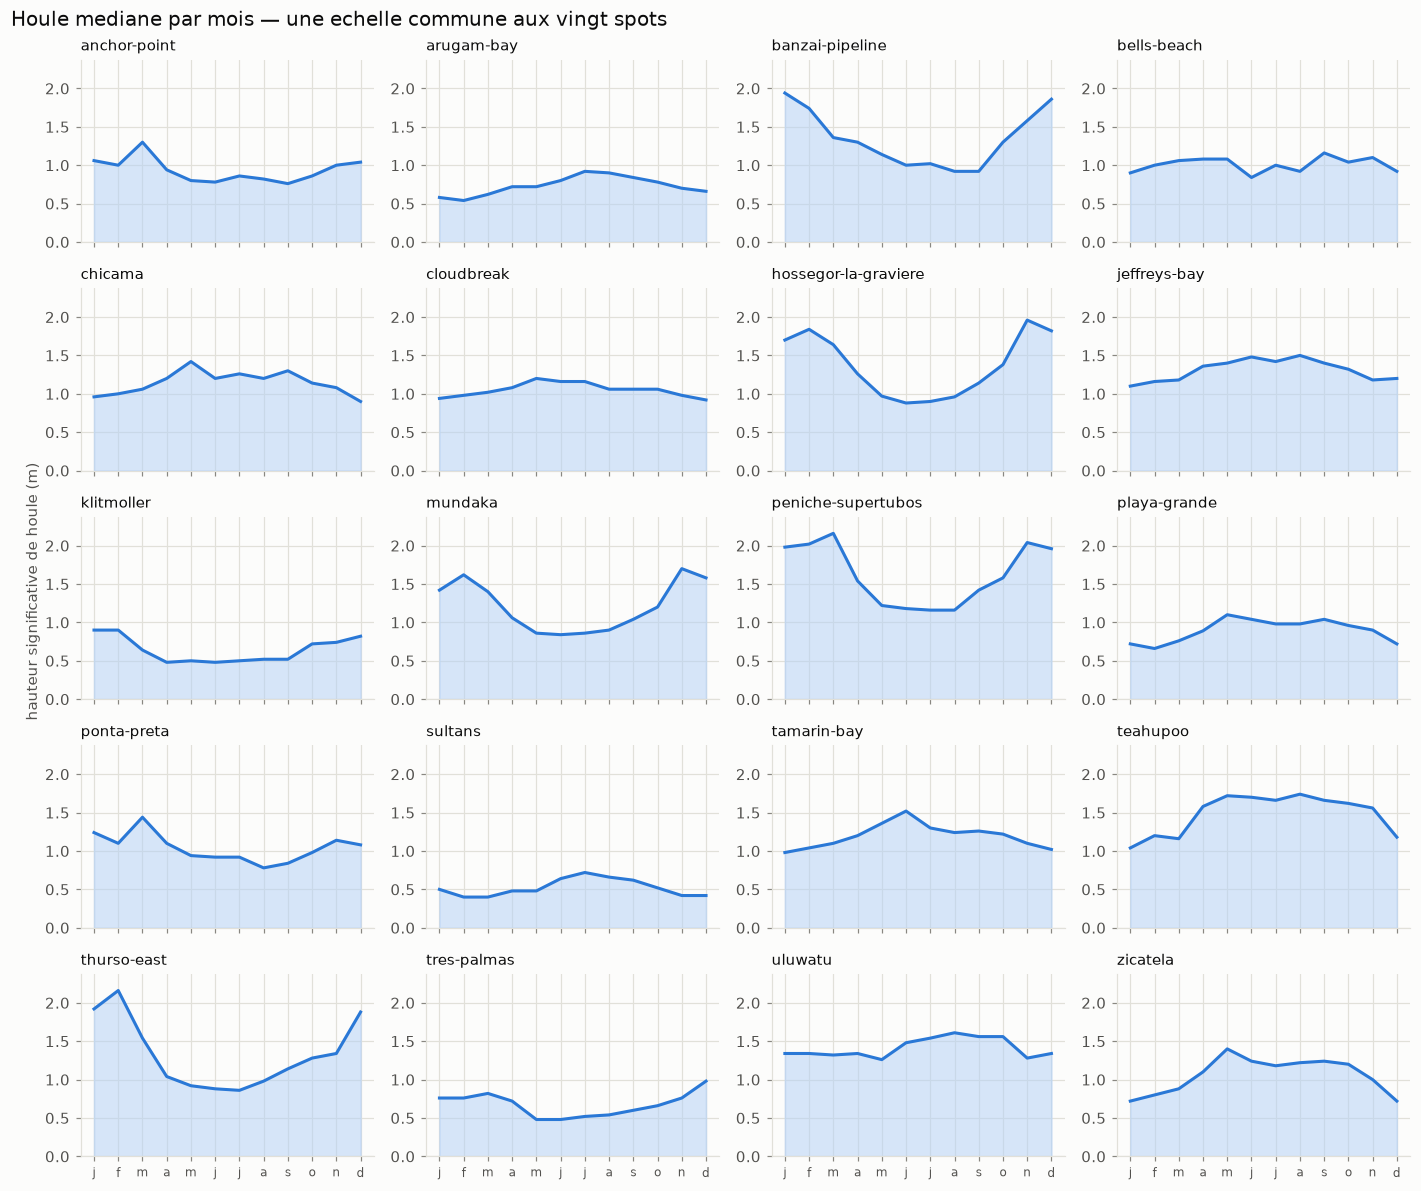

In [9]:
mensuel = (
    heures.with_columns(pl.col("time").dt.month().alias("mois"))
    .group_by("spot_id", "mois")
    .agg(pl.col(SWELL_HEIGHT).median().alias("houle_mediane"))
    .sort("spot_id", "mois")
)

noms = sorted(spots)
fig, axes = plt.subplots(5, 4, figsize=(13, 11), sharex=True)
MOIS = ["j", "f", "m", "a", "m", "j", "j", "a", "s", "o", "n", "d"]

for ax, nom in zip(axes.ravel(), noms, strict=False):
    serie = mensuel.filter(pl.col("spot_id") == nom).sort("mois")
    ax.plot(serie["mois"], serie["houle_mediane"], color=CLAIR["serie"])
    ax.fill_between(serie["mois"], 0, serie["houle_mediane"],
                    color=CLAIR["serie_attenuee"], alpha=0.55)
    ax.set_title(nom, loc="left", fontsize=9.5)
    ax.set_xticks(range(1, 13), MOIS, fontsize=8)
    ax.set_ylim(0, float(mensuel["houle_mediane"].max()) * 1.1)

fig.suptitle("Houle mediane par mois — une echelle commune aux vingt spots",
             x=0.01, ha="left", fontsize=13)
fig.supylabel("hauteur significative de houle (m)", fontsize=10, color=CLAIR["encre_2"])
plt.tight_layout()
plt.show()

**Une seule échelle pour les vingt panneaux.** Laisser matplotlib choisir une
échelle par panneau donnerait à Klitmøller l'allure de Teahupo'o. L'échelle commune
est ce qui rend les petits multiples comparables — c'est leur seul intérêt.

On lit directement les deux hémisphères : les spots européens et marocains culminent
en décembre-janvier, les spots austraux et indonésiens en juin-août. C'est le signal
que le score exploite.

## Ce que ce notebook établit

- Le cache est **complet** : aucun couple spot-année au-dessus du seuil d'alerte.
- La mer totale surestime la houle de façon systématique. La décision de perdre six
  ans d'archive pour garder la houle pure est **mesurée**, pas postulée.
- La conversion de période place les seuils dans un domaine plausible, **sans qu'on
  puisse la valider directement** — la période de pic n'est pas servie. Limite
  assumée, à rapprocher des spots muets du notebook 02.